# Lab 1 – Spectral Analysis of Deterministic Signals

## Variant 6

**Student:** Maciej Grochowski  
**Laboratory:** Spectral Analysis of Deterministic Signals


## 1. Objective

The objective of this laboratory is to synthesize a discrete-time signal
using the inverse discrete Fourier transform (IDFT) implemented as
a matrix multiplication.

For Variant 6, the DFT coefficient vector is:

\[
X = [7,2,4,3,4,5,0,0,0,0]^T
\]

The signal is synthesized using the Fourier matrix according to:

\[
\mathbf{x} = \frac{1}{N}W\mathbf{X}
\]

where \(N\) is the signal length and \(W\) is the Fourier matrix.


## 2. Theoretical Background

The inverse discrete Fourier transform is defined as:

\[
x[k] = \frac{1}{N}\sum_{\mu=0}^{N-1}
X[\mu]e^{j2\pi k\mu/N}
\]

The IDFT can also be represented as a matrix operation:

\[
\mathbf{x} = \frac{1}{N}W\mathbf{X}
\]

The Fourier matrix is defined as:

\[
W[k,\mu] = e^{j2\pi k\mu/N}
\]

The matrix \(K\) contains all products of the sample index \(k\)
and frequency index \(\mu\):

\[
K[k,\mu] = k\mu
\]

Therefore, the Fourier matrix can be constructed as:

\[
W=e^{j2\pi K/N}
\]


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Variant 6 - input data

X = np.array([7, 2, 4, 3, 4, 5, 0, 0, 0, 0], dtype=complex)

N = len(X)

print("N =", N)
print("X =", X)


N = 10
X = [7.+0.j 2.+0.j 4.+0.j 3.+0.j 4.+0.j 5.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


## 3. Construction of the K Matrix

The matrix \(K\) contains all products of the sample index \(k\)
and the frequency index \(\mu\):

\[
K[k,\mu] = k\mu
\]

For \(N=10\), the matrix \(K\) has dimensions \(10\times10\).


In [3]:
# Construction of the K matrix

k = np.arange(N)
mu = np.arange(N)

K = np.outer(k, mu)

print("K matrix:")
print(K)


K matrix:
[[ 0  0  0  0  0  0  0  0  0  0]
 [ 0  1  2  3  4  5  6  7  8  9]
 [ 0  2  4  6  8 10 12 14 16 18]
 [ 0  3  6  9 12 15 18 21 24 27]
 [ 0  4  8 12 16 20 24 28 32 36]
 [ 0  5 10 15 20 25 30 35 40 45]
 [ 0  6 12 18 24 30 36 42 48 54]
 [ 0  7 14 21 28 35 42 49 56 63]
 [ 0  8 16 24 32 40 48 56 64 72]
 [ 0  9 18 27 36 45 54 63 72 81]]


## 4. Construction of the Fourier Matrix W

The Fourier matrix is constructed from the matrix \(K\) using:

\[
W=e^{j2\pi K/N}
\]

For this experiment, \(N=10\).


In [4]:
# Construction of the Fourier matrix W

W = np.exp(1j * 2 * np.pi * K / N)

print("Fourier matrix W:")
print(np.round(W, 4))


Fourier matrix W:
[[ 1.   +0.j      1.   +0.j      1.   +0.j      1.   +0.j
   1.   +0.j      1.   +0.j      1.   +0.j      1.   +0.j
   1.   +0.j      1.   +0.j    ]
 [ 1.   +0.j      0.809+0.5878j  0.309+0.9511j -0.309+0.9511j
  -0.809+0.5878j -1.   +0.j     -0.809-0.5878j -0.309-0.9511j
   0.309-0.9511j  0.809-0.5878j]
 [ 1.   +0.j      0.309+0.9511j -0.809+0.5878j -0.809-0.5878j
   0.309-0.9511j  1.   -0.j      0.309+0.9511j -0.809+0.5878j
  -0.809-0.5878j  0.309-0.9511j]
 [ 1.   +0.j     -0.309+0.9511j -0.809-0.5878j  0.809-0.5878j
   0.309+0.9511j -1.   +0.j      0.309-0.9511j  0.809+0.5878j
  -0.809+0.5878j -0.309-0.9511j]
 [ 1.   +0.j     -0.809+0.5878j  0.309-0.9511j  0.309+0.9511j
  -0.809-0.5878j  1.   -0.j     -0.809+0.5878j  0.309-0.9511j
   0.309+0.9511j -0.809-0.5878j]
 [ 1.   +0.j     -1.   +0.j      1.   -0.j     -1.   +0.j
   1.   -0.j     -1.   -0.j      1.   -0.j     -1.   +0.j
   1.   -0.j     -1.   -0.j    ]
 [ 1.   +0.j     -0.809-0.5878j  0.309+0.9511j  0.309-0.

## 5. IDFT Using Matrix Multiplication

The time-domain signal is synthesized using the matrix form of the
inverse discrete Fourier transform:

\[
\mathbf{x}=\frac{1}{N}W\mathbf{X}
\]

For Variant 6, \(N=10\).


In [11]:
# IDFT using matrix multiplication

x = (1 / N) * W @ X

print("Synthesized signal x[k]:")
print(np.real_if_close(x))


Synthesized signal x[k]:
[2.5      +0.00000000e+00j 0.0690983+1.01841071e+00j
 0.8190983-1.31432778e-01j 0.1809017+1.59184233e-01j
 0.9309017-2.12662702e-01j 0.5      -7.41220804e-16j
 0.9309017+2.12662702e-01j 0.1809017-1.59184233e-01j
 0.8190983+1.31432778e-01j 0.0690983-1.01841071e+00j]


In [12]:
print("Real part:")
print(np.real(x))

print("\nImaginary part:")
print(np.imag(x))


Real part:
[2.5       0.0690983 0.8190983 0.1809017 0.9309017 0.5       0.9309017
 0.1809017 0.8190983 0.0690983]

Imaginary part:
[ 0.00000000e+00  1.01841071e+00 -1.31432778e-01  1.59184233e-01
 -2.12662702e-01 -7.41220804e-16  2.12662702e-01 -1.59184233e-01
  1.31432778e-01 -1.01841071e+00]


In [6]:
for i, value in enumerate(np.real_if_close(x)):
    print(f"x[{i}] = {value}")


x[0] = (2.5000000000000004+0j)
x[1] = (0.06909830056250543+1.0184107127820914j)
x[2] = (0.8190983005625052-0.13143277802978345j)
x[3] = (0.1809016994374949+0.1591842331723611j)
x[4] = (0.9309016994374946-0.21266270208801016j)
x[5] = (0.5-7.41220803802443e-16j)
x[6] = (0.9309016994374948+0.21266270208800975j)
x[7] = (0.18090169943749435-0.15918423317236022j)
x[8] = (0.8190983005625055+0.13143277802978307j)
x[9] = (0.06909830056250477-1.0184107127820925j)


## 6. Plot of the Synthesized Signal

The synthesized signal \(x[k]\) is a complex-valued discrete-time signal.
Therefore, both its real and imaginary parts are presented.


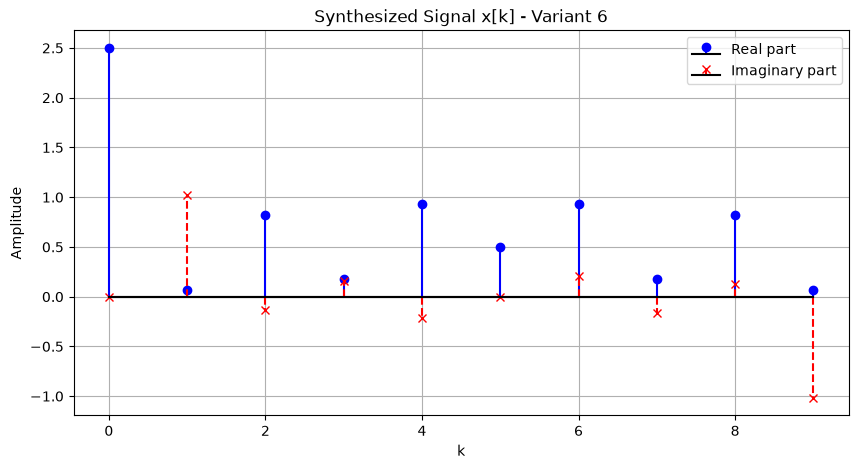

In [7]:
# Plot of the real and imaginary parts of x[k]

plt.figure(figsize=(10, 5))

plt.stem(np.arange(N), np.real(x), linefmt='b-', markerfmt='bo',
         basefmt='k-', label='Real part')

plt.stem(np.arange(N), np.imag(x), linefmt='r--', markerfmt='rx',
         basefmt='k-', label='Imaginary part')

plt.xlabel("k")
plt.ylabel("Amplitude")
plt.title("Synthesized Signal x[k] - Variant 6")
plt.legend()
plt.grid(True)

plt.show()


## 7. Verification Using NumPy

To verify the matrix implementation, the result is compared with the
built-in `numpy.fft.ifft()` function.


In [13]:
# Verification using NumPy

x_numpy = np.fft.ifft(X)

print("IDFT using matrix multiplication:")
print(x)

print("\nIDFT using NumPy:")
print(x_numpy)

error = np.max(np.abs(x - x_numpy))

print("\nMaximum absolute error:")
print(error)


IDFT using matrix multiplication:
[2.5      +0.00000000e+00j 0.0690983+1.01841071e+00j
 0.8190983-1.31432778e-01j 0.1809017+1.59184233e-01j
 0.9309017-2.12662702e-01j 0.5      -7.41220804e-16j
 0.9309017+2.12662702e-01j 0.1809017-1.59184233e-01j
 0.8190983+1.31432778e-01j 0.0690983-1.01841071e+00j]

IDFT using NumPy:
[2.5      +0.00000000e+00j 0.0690983+1.01841071e+00j
 0.8190983-1.31432778e-01j 0.1809017+1.59184233e-01j
 0.9309017-2.12662702e-01j 0.5      +4.44089210e-17j
 0.9309017+2.12662702e-01j 0.1809017-1.59184233e-01j
 0.8190983+1.31432778e-01j 0.0690983-1.01841071e+00j]

Maximum absolute error:
1.2118257228641697e-15


The maximum absolute error between the matrix-based IDFT and
`numpy.fft.ifft()` is approximately:

\[
1.21\times10^{-15}
\]

This value is effectively zero for numerical calculations and confirms
that the matrix implementation produces the same result as the standard
NumPy IDFT implementation.


## 8. Verification of the Fourier Matrix Properties

The Fourier matrix has the important property:

\[
W^H W = NI
\]

where \(W^H\) is the conjugate transpose of \(W\) and \(I\) is the
identity matrix.

For this experiment \(N=10\), therefore:

\[
W^H W = 10I
\]

This property is verified numerically below.


In [9]:
# Verification of W^H W = N I

WH = W.conj().T

result = WH @ W

print("W^H W:")
print(np.round(result, 6))


W^H W:
[[10.+0.j -0.+0.j -0.+0.j -0.+0.j  0.+0.j  0.-0.j -0.+0.j -0.+0.j  0.+0.j
  -0.-0.j]
 [-0.+0.j 10.+0.j -0.+0.j -0.-0.j  0.+0.j  0.-0.j -0.-0.j  0.-0.j  0.+0.j
   0.+0.j]
 [-0.-0.j -0.-0.j 10.+0.j  0.-0.j -0.+0.j  0.-0.j  0.+0.j  0.-0.j  0.+0.j
  -0.-0.j]
 [-0.-0.j -0.+0.j  0.+0.j 10.+0.j -0.+0.j  0.+0.j -0.+0.j -0.-0.j  0.+0.j
  -0.+0.j]
 [ 0.-0.j  0.-0.j -0.-0.j -0.-0.j 10.+0.j  0.+0.j -0.-0.j  0.+0.j -0.+0.j
  -0.-0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-0.j  0.-0.j 10.+0.j  0.-0.j -0.-0.j -0.+0.j
   0.+0.j]
 [-0.-0.j -0.+0.j  0.-0.j -0.-0.j -0.+0.j  0.+0.j 10.+0.j -0.+0.j  0.+0.j
   0.-0.j]
 [-0.-0.j  0.+0.j  0.+0.j -0.+0.j  0.-0.j -0.+0.j -0.-0.j 10.+0.j -0.+0.j
  -0.+0.j]
 [ 0.-0.j  0.-0.j  0.-0.j  0.-0.j -0.-0.j -0.-0.j  0.-0.j -0.-0.j 10.+0.j
   0.-0.j]
 [-0.+0.j  0.-0.j -0.+0.j -0.-0.j -0.+0.j  0.-0.j  0.+0.j -0.-0.j  0.+0.j
  10.+0.j]]


## 9. Normalized Fourier Matrix

The normalized Fourier matrix is defined as:

\[
W_u=\frac{W}{\sqrt{N}}
\]

For the normalized matrix, the following property holds:

\[
W_u^H W_u=I
\]

This means that the normalized Fourier matrix is unitary.


In [10]:
# Normalized Fourier matrix

W_unitary = W / np.sqrt(N)

identity_check = W_unitary.conj().T @ W_unitary

print("W_unitary^H W_unitary:")
print(np.round(identity_check, 6))


W_unitary^H W_unitary:
[[ 1.+0.j -0.+0.j -0.-0.j -0.+0.j -0.+0.j  0.-0.j -0.+0.j -0.+0.j  0.+0.j
  -0.-0.j]
 [-0.-0.j  1.+0.j -0.-0.j -0.-0.j -0.+0.j  0.-0.j -0.-0.j  0.-0.j  0.+0.j
  -0.+0.j]
 [-0.+0.j -0.+0.j  1.+0.j  0.+0.j -0.+0.j  0.-0.j  0.+0.j  0.-0.j  0.+0.j
  -0.-0.j]
 [-0.-0.j -0.+0.j  0.-0.j  1.+0.j -0.+0.j  0.+0.j -0.+0.j -0.-0.j -0.+0.j
  -0.+0.j]
 [-0.-0.j -0.-0.j -0.-0.j -0.-0.j  1.+0.j  0.+0.j -0.-0.j  0.+0.j -0.+0.j
   0.-0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-0.j  0.-0.j  1.+0.j  0.-0.j -0.-0.j -0.+0.j
   0.+0.j]
 [-0.-0.j -0.+0.j  0.-0.j -0.-0.j -0.+0.j  0.+0.j  1.+0.j -0.+0.j  0.+0.j
   0.-0.j]
 [-0.-0.j  0.+0.j  0.+0.j -0.+0.j  0.-0.j -0.+0.j -0.-0.j  1.+0.j -0.+0.j
  -0.+0.j]
 [ 0.-0.j  0.-0.j  0.-0.j -0.-0.j -0.-0.j -0.-0.j  0.-0.j -0.-0.j  1.+0.j
   0.-0.j]
 [-0.+0.j -0.-0.j -0.+0.j -0.-0.j  0.+0.j  0.-0.j  0.+0.j -0.-0.j  0.+0.j
   1.+0.j]]


## 10. Conclusions

In this laboratory, the inverse discrete Fourier transform was implemented
using matrix multiplication.

For Variant 6, the input vector of DFT coefficients was:

\[
X=[7,2,4,3,4,5,0,0,0,0]^T
\]

The signal length was \(N=10\).

First, the matrix \(K\) containing all products \(k\mu\) was constructed.
Then, the Fourier matrix \(W\) was calculated according to:

\[
W=e^{j2\pi K/N}
\]

The time-domain signal was synthesized using:

\[
\mathbf{x}=\frac{1}{N}W\mathbf{X}
\]

The obtained signal was complex-valued. Its real and imaginary parts were
presented on a discrete-time plot.

The matrix implementation was verified by comparing the result with the
`numpy.fft.ifft()` function. Both methods produced practically identical
results, with only a very small numerical error caused by floating-point
calculations.

Additionally, the property

\[
W^H W=NI
\]

was verified numerically. The normalized Fourier matrix was also checked
and confirmed to satisfy the unitary property:

\[
W_u^H W_u=I
\]

The experiment demonstrates how the IDFT can be implemented directly as
a matrix operation using the Fourier matrix.
